# Deep Learning - Autoencoder ile Anormal Sektör Tespiti

Autoencoder, girdiyi önce sıkıştırıp sonra yeniden oluşturmaya çalışan bir yapay sinir ağıdır. Normal verileri iyi yeniden oluşturur, alışılmadık verilerde ise hata büyür. Bu hatayı kullanarak emisyon profili **anormal** olan sektörleri bulacağız.

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',100)

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
df=pd.read_csv('ghg_data.csv')

In [4]:
sutunlar=['Supply Chain Emission Factors without Margins','Margins of Supply Chain Emission Factors','Supply Chain Emission Factors with Margins']
x=df[sutunlar].clip(lower=0)
x.describe()

,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins
count,1016.000000,1016.000000,1016.000000
mean,0.264994,0.016945,0.281898
std,0.314768,0.023367,0.321417
min,0.026000,0.000000,0.029000
25%,0.103000,0.000000,0.108000
50%,0.159000,0.000000,0.173000
75%,0.302250,0.030250,0.329250
max,3.846000,0.125000,3.924000


Değerler çok çarpık dağıldığı için log dönüşümü ve standartlaştırma uyguluyoruz.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
xs=scaler.fit_transform(np.log1p(x.values)).astype('float32')

In [6]:
model=keras.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(8,activation='relu'),
    layers.Dense(2,activation='relu'),   # sıkıştırılmış temsil
    layers.Dense(8,activation='relu'),
    layers.Dense(3)
])
model.compile(optimizer='adam',loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              18 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
gecmis=model.fit(xs,xs,epochs=100,batch_size=32,validation_split=.1,verbose=0)

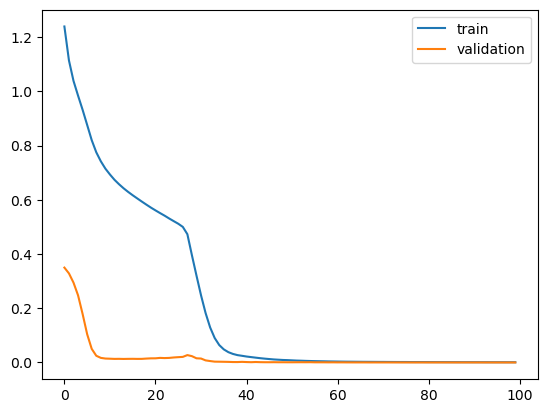

In [8]:
plt.plot(gecmis.history['loss'],label='train')
plt.plot(gecmis.history['val_loss'],label='validation')
plt.legend()
plt.show()

In [9]:
hata=np.mean((xs-model.predict(xs))**2,axis=1)
esik=float(np.percentile(hata,95))
esik

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


0.003908063285052776

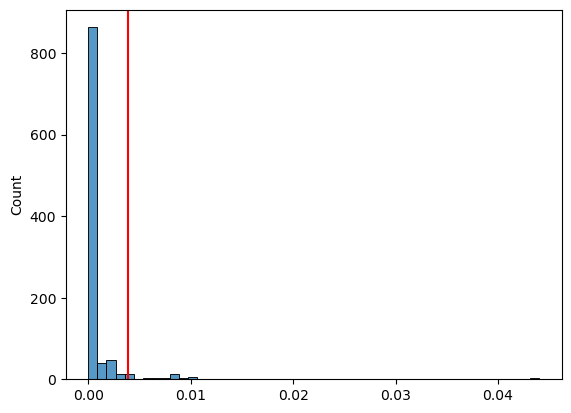

In [10]:
sns.histplot(hata,bins=50)
plt.axvline(esik,color='red')
plt.show()

In [11]:
df['hata']=hata
df.sort_values('hata',ascending=False)[['2017 NAICS Title']+sutunlar+['hata']].head(10)

,2017 NAICS Title,Supply Chain Emission Factors without Margins,Margins of Supply Chain Emission Factors,Supply Chain Emission Factors with Margins,hata
656,All Other Pipeline Transportation,1.619,0.000,1.619,0.044043
653,Pipeline Transportation of Crude Oil,1.619,0.000,1.619,0.044043
655,Pipeline Transportation of Refined Petroleum P...,1.619,0.000,1.619,0.044043
654,Pipeline Transportation of Natural Gas,1.619,0.000,1.619,0.044043
448,Other Aircraft Parts and Auxiliary Equipment M...,0.163,0.007,0.170,0.013027
92,Natural Gas Distribution,0.532,0.000,0.532,0.011698
447,Aircraft Engine and Engine Parts Manufacturing,0.151,0.005,0.156,0.010577
623,Scheduled Passenger Air Transportation,0.644,0.000,0.644,0.010457
624,Scheduled Freight Air Transportation,0.644,0.000,0.644,0.010457
625,Nonscheduled Chartered Passenger Air Transport...,0.644,0.000,0.644,0.010457


In [12]:
import pickle
model.save('ghg_autoencoder.keras')
pickle.dump(scaler,open('ae_scaler.pkl','wb'))
pickle.dump(esik,open('ae_esik.pkl','wb'))